In [47]:
import pandas as pd

df=pd.read_csv(r"C:\Users\Lohith\OneDrive\Desktop\Heart_disease_prediction\data\heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [48]:
df.shape

(1025, 14)

In [49]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [50]:
df.duplicated().sum()
df = df.drop_duplicates()

In [51]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [52]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [53]:
df.columns


Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

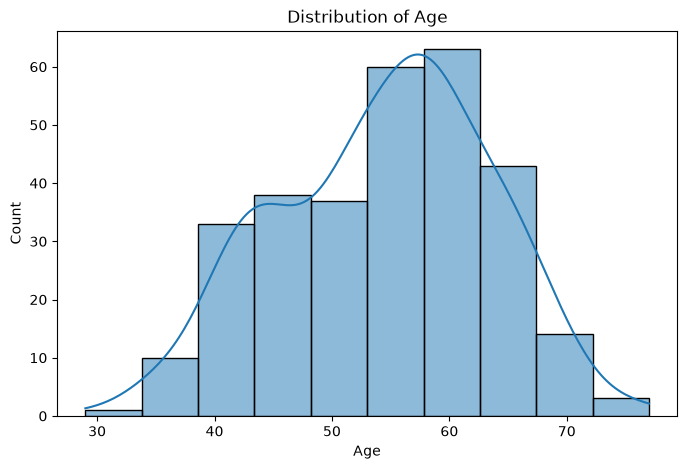

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=10, kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

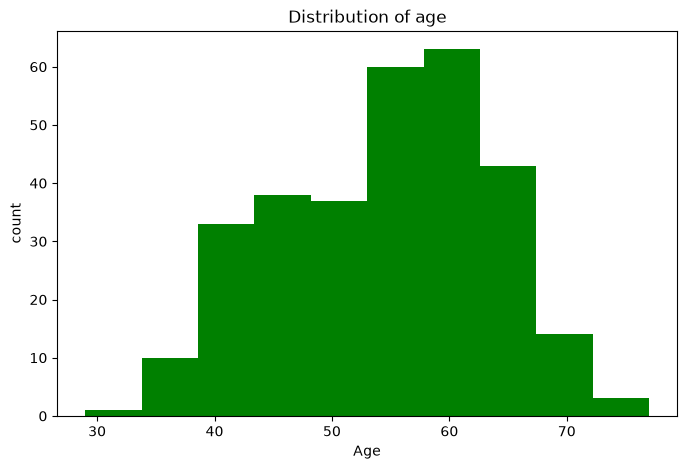

In [55]:
plt.figure(figsize=(8,5))
plt.hist(df['age'],color='green')
plt.title('Distribution of age')
plt.xlabel('Age')
plt.ylabel('count')
plt.show()

In [56]:
corr_matrix=df.corr(numeric_only=True)
corr_matrix["target"].sort_values(ascending=False)

target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64

In [57]:
from sklearn.model_selection import train_test_split

x=df.drop("target",axis=1)
y=df["target"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier


In [59]:
models={
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "KNN":KNeighborsClassifier(),
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "Random forest":RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)

}

In [60]:
from sklearn.metrics import accuracy_score

results={}

for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    accuracy=accuracy_score(y_test,y_pred)
    results[name]=accuracy

c:\Users\Lohith\OneDrive\Desktop\Heart_disease_prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [61]:
for model, score in results.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.8033
KNN: 0.6393
Decision Tree: 0.7377
Random forest: 0.8361
SVM: 0.5902
Naive Bayes: 0.8525
Gradient Boosting: 0.8033


In [62]:
import pandas as pd

result_df = pd.DataFrame(
    results.items(),
    columns=["Model", "Accuracy"]
)

result_df = result_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(result_df)

                 Model  Accuracy
5          Naive Bayes  0.852459
3        Random forest  0.836066
0  Logistic Regression  0.803279
6    Gradient Boosting  0.803279
2        Decision Tree  0.737705
1                  KNN  0.639344
4                  SVM  0.590164


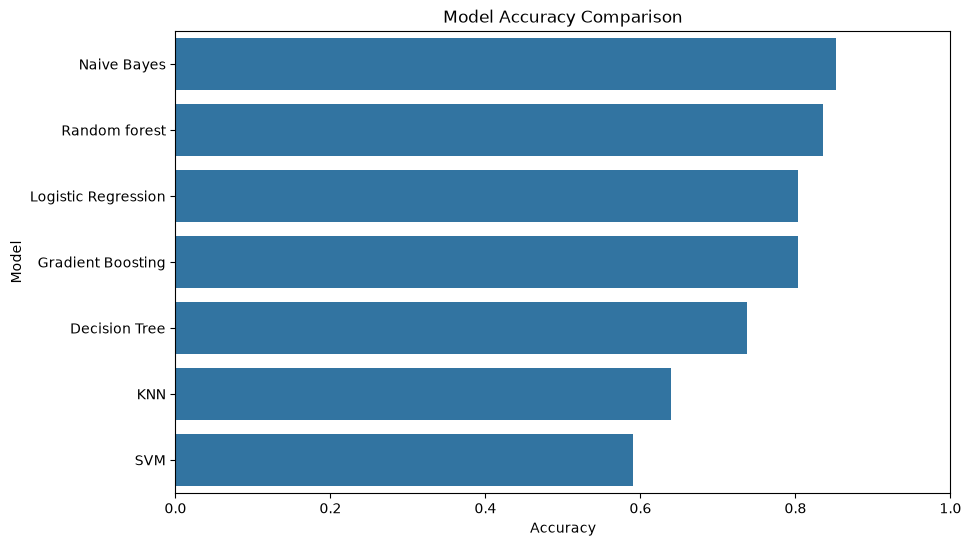

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=result_df,
    x="Accuracy",
    y="Model"
)

plt.title("Model Accuracy Comparison")
plt.xlim(0,1)

plt.show()

In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
import pandas as pd

In [65]:
results = []

for name, model in models.items():

    # Train the model
    model.fit(x_train, y_train)

    # Make predictions
    y_pred = model.predict(x_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    # Store the results
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

c:\Users\Lohith\OneDrive\Desktop\Heart_disease_prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [66]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
5          Naive Bayes  0.852459   0.833333  0.862069  0.847458  0.852909
3        Random forest  0.836066   0.787879  0.896552  0.838710  0.838901
0  Logistic Regression  0.803279   0.742857  0.896552  0.812500  0.807651
6    Gradient Boosting  0.803279   0.757576  0.862069  0.806452  0.806034
2        Decision Tree  0.737705   0.740741  0.689655  0.714286  0.735453
1                  KNN  0.639344   0.581395  0.862069  0.694444  0.649784
4                  SVM  0.590164   0.545455  0.827586  0.657534  0.601293


In [67]:
for name, model in models.items():

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    print(f"\n{name}")
    print(confusion_matrix(y_test, y_pred))

c:\Users\Lohith\OneDrive\Desktop\Heart_disease_prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
[[23  9]
 [ 3 26]]

KNN
[[14 18]
 [ 4 25]]

Decision Tree
[[25  7]
 [ 9 20]]

Random forest
[[25  7]
 [ 3 26]]

SVM
[[12 20]
 [ 5 24]]

Naive Bayes
[[27  5]
 [ 4 25]]

Gradient Boosting
[[24  8]
 [ 4 25]]


c:\Users\Lohith\OneDrive\Desktop\Heart_disease_prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


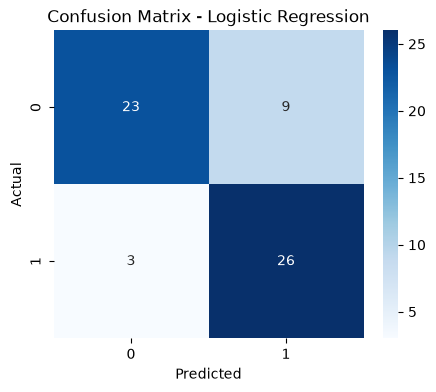

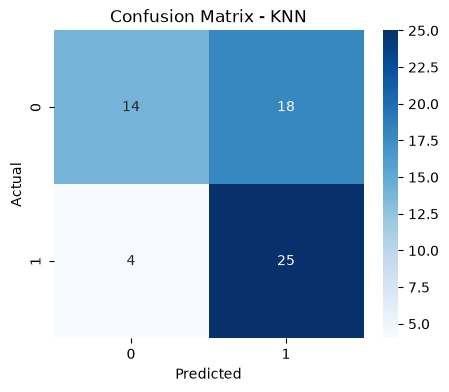

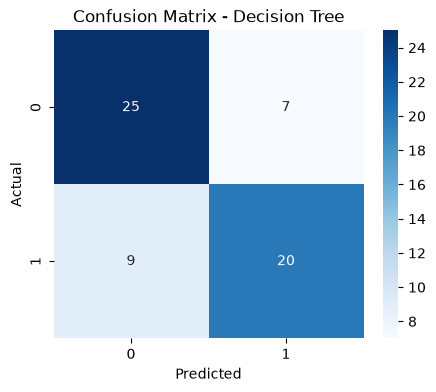

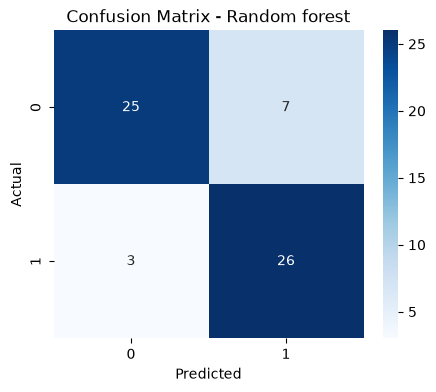

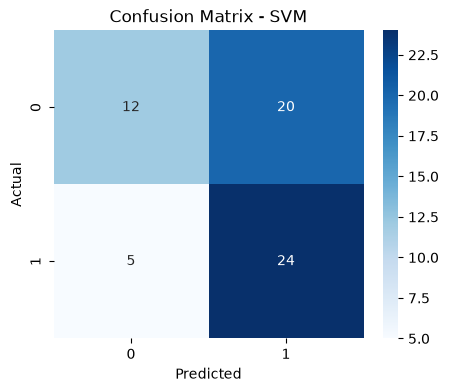

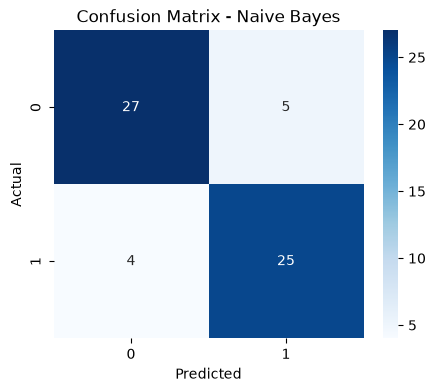

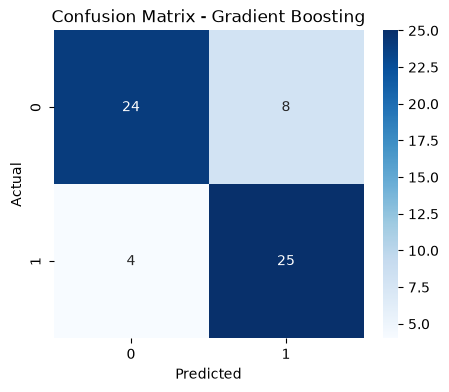

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [69]:
from sklearn.metrics import classification_report

for name, model in models.items():

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))

c:\Users\Lohith\OneDrive\Desktop\Heart_disease_prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.72      0.79        32
           1       0.74      0.90      0.81        29

    accuracy                           0.80        61
   macro avg       0.81      0.81      0.80        61
weighted avg       0.82      0.80      0.80        61


KNN
              precision    recall  f1-score   support

           0       0.78      0.44      0.56        32
           1       0.58      0.86      0.69        29

    accuracy                           0.64        61
   macro avg       0.68      0.65      0.63        61
weighted avg       0.68      0.64      0.62        61


Decision Tree
              precision    recall  f1-score   support

           0       0.74      0.78      0.76        32
           1       0.74      0.69      0.71        29

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74

In [70]:
model=GaussianNB()
model.fit(x_train,y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[106.,135.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.44,0.56]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,2.871e-06
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['age','sex','cp',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 13)","[[56.61, 0.86, 0.47,..., 1.15, 1.16, 2.57], [52.45, 0.54, 1.42,..., 1.63, 0.38, 2.14]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 13)","[[65.9 , 0.12, 0.8 ,..., 0.3 , 1.12, 0.47], [91.83, 0.25, 0.85,..., 0.28, 0.72, 0.2 ]]"


In [71]:
import joblib

joblib.dump(model, "heart_disease_model.pkl")

['heart_disease_model.pkl']